# Train, save, reload, and compare a field model

**Learning objective.** Train a neural model for a linear Helmholtz-like field, preserve its input conventions in a checkpoint, and interpret predictions at held-out loads.

**Predict first.** How would mixing nodes from the same load case across training and test sets change the meaning of the test error?

Follow the worked calculation, then use the downloadable notebook to explore the exercises.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CEMS-Lab/autumn-school/blob/main/notebooks/study/04_train_save_reload_adapter.ipynb)

[Download practice notebook](https://cems-lab.github.io/autumn-school/notebooks/study/04_train_save_reload_adapter.ipynb) · [Download with worked solutions](https://cems-lab.github.io/autumn-school/notebooks/solutions/04_train_save_reload_adapter.ipynb) · [Environment setup](https://cems-lab.github.io/autumn-school/SETUP.md) · [Read this lesson in the book](https://cems-lab.github.io/autumn-school/book/labs/04_train_save_reload_adapter.html)

A numerical field solver can generate examples at selected loading conditions. A neural network can then learn the relation between position, load, and field value. Saving the learned weights together with the input conventions makes the model reusable in a later calculation.

Here, `ToyHelmholtzProblem` supplies a small, course-owned linear field model on a unit square:

$$
d-\ell^2\nabla^2d=b(\mathbf{x},\lambda),
\qquad d=0\quad\text{on the boundary}.
$$

The dimensionless scalar $d$ is a damage-like teaching field, $\ell$ controls spatial smoothing, and $b$ is a smooth source scaled by the dimensionless load factor $\lambda$. A finite-difference discretisation gives $A\mathbf{d}=\mathbf{b}$. Reference solutions provide training targets; the same discrete equation supplies a residual for the next tutorial.

## From reference fields to a training objective

Each node supplies one feature row $\mathbf{x}_i=[x_i/L,y_i/H,\lambda]$. The feature tensor has shape $(N,3)$ and the network output has shape $(N,1)$. All three inputs are dimensionless and retain this order throughout training and inference.

The data contain 12 whole training load cases, two validation cases, and two test cases. All nodes from one load case stay in the same split. The mean $\boldsymbol\mu$ and scale $\boldsymbol\sigma$ are computed from training features and reused for every prediction:

$$
\mathbf{z}_i=\frac{\mathbf{x}_i-\boldsymbol\mu}{\boldsymbol\sigma},
\qquad
\widehat d_i=f_{\boldsymbol\theta}(\mathbf{z}_i),
\qquad
\mathcal L(\boldsymbol\theta)=\frac1M\sum_{i=1}^{M}(\widehat d_i-d_i)^2.
$$

Here $M$ is the number of training rows and $\boldsymbol\theta$ contains all network weights and biases. The final sigmoid maps the predicted scalar into $(0,1)$.

## Read the training step

The first calculation below calls `make_toy_checkpoint` for 400 epochs. Inside that helper, each epoch performs these operations:

```python
optimizer.zero_grad(set_to_none=True)
prediction = model(normalise_features(train_x, mean, scale))
loss = torch.mean((prediction - train_y) ** 2)
loss.backward()
optimizer.step()
```

`loss.backward()` propagates the scalar loss through the network and stores parameter gradients. Adam uses those gradients in `optimizer.step()`. Validation fields monitor prediction quality at separate loads. The checkpoint records the weights, architecture, normalisation, feature order, mesh signature, data splits, and training history.

The following cells train and save the MLP, reconstruct a fresh instance, compare its predictions with the saved in-memory weights, and evaluate a Gaussian radial-basis weighted-average baseline using the same features.


In [1]:
# Environment setup is measured separately from the classroom computation.
from pathlib import Path
import importlib.metadata
import json
import os
import subprocess
import sys
import time

setup_started = time.perf_counter()
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if not (3, 10) <= sys.version_info[:2] < (3, 13):
    raise RuntimeError("This PhAST snapshot supports Python 3.10–3.12. Select a compatible runtime; see Environment Setup.")

def locate_course_root():
    for base in (Path.cwd(), *Path.cwd().parents):
        for candidate in (base, base / "autumn-school", base / "teaching/ukacm_autumn_school_2026"):
            if (candidate / "notebooks/day2_helpers").is_dir() and (candidate / "vendor/PhAST/src").is_dir():
                return candidate.resolve()
    return None

COURSE_ROOT = locate_course_root()
if COURSE_ROOT is None and IN_COLAB:
    COURSE_ROOT = Path.cwd() / "autumn-school"
    if COURSE_ROOT.exists():
        raise RuntimeError("An incomplete autumn-school folder exists. Start a fresh runtime or select the complete course folder.")
    # A release tag or full commit can be supplied for a fixed course edition.
    course_ref = os.environ.get("PHAST_COURSE_REF", "main")
    subprocess.run(["git", "init", str(COURSE_ROOT)], check=True, capture_output=True)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "remote", "add", "origin", "https://github.com/CEMS-Lab/autumn-school.git"], check=True)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "fetch", "--depth", "1", "origin", course_ref], check=True, timeout=180)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "checkout", "--detach", "FETCH_HEAD"], check=True, capture_output=True)
if COURSE_ROOT is None:
    raise FileNotFoundError("Open the notebook from the complete course folder, including notebooks/, configs/ and vendor/. See Environment Setup.")

if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", str(COURSE_ROOT / "vendor/PhAST"), "nbformat", "nbclient", "nbconvert"], check=True, timeout=600)

for package_dir in (COURSE_ROOT / "vendor/PhAST/src", COURSE_ROOT / "notebooks"):
    if str(package_dir) not in sys.path:
        sys.path.insert(0, str(package_dir))

revision = subprocess.run(["git", "-C", str(COURSE_ROOT), "rev-parse", "HEAD"], text=True, capture_output=True)
package_versions = {}
for package in ("torch", "numpy", "scipy", "matplotlib", "nbformat"):
    try:
        package_versions[package] = importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        package_versions[package] = "install using Environment Setup"
setup_receipt = {
    "environment": "Google Colab" if IN_COLAB else "local",
    "python": sys.version.split()[0],
    "course_revision": revision.stdout.strip() if revision.returncode == 0 else "downloaded archive",
    "versions": package_versions,
    "setup_seconds": round(time.perf_counter() - setup_started, 3),
}
print(setup_receipt)

import matplotlib.pyplot as plt
import numpy as np
import torch
from io import BytesIO
from IPython.display import Image, display
from day2_helpers import assets_dir

torch.set_default_dtype(torch.float64)
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
    "font.size": 11, "axes.labelsize": 11, "axes.titlesize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10,
    "figure.titlesize": 13, "figure.dpi": 150, "axes.grid": True,
    "grid.alpha": 0.3, "grid.linestyle": "--", "lines.linewidth": 1.8,
})

def display_figure(figure, dpi=150, alt="Rendered teaching figure"):
    """Retain figures for reading in the book and in a fresh notebook session."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buffer.getvalue(), alt=alt))


{'environment': 'local', 'python': '3.10.18', 'course_revision': '077d43d87c55b4fdea720808fc24f040e957e1ea', 'versions': {'torch': '2.8.0', 'numpy': '2.2.6', 'scipy': '1.14.1', 'matplotlib': '3.10.8', 'nbformat': '5.10.4'}, 'setup_seconds': 0.016}


In [2]:
from day2_helpers.course_tools import (
    FEATURE_ORDER, TinyDamageMLP, ToyHelmholtzProblem,
    load_toy_model, make_toy_checkpoint, normalise_features,
)

checkpoint_path = assets_dir() / "models" / "tiny_damage_mlp.pt"
checkpoint = make_toy_checkpoint(checkpoint_path, epochs=400, force=True)
metadata = checkpoint["metadata"]
print({"checkpoint": str(checkpoint_path.relative_to(COURSE_ROOT)), "metadata": metadata, "history": checkpoint["history"], "metrics": checkpoint["metrics"]})


{'checkpoint': 'assets/day2_forward/models/tiny_damage_mlp.pt', 'metadata': {'interface_version': 'ukacm-toy-damage-v1', 'architecture': 'TinyDamageMLP', 'width': 32, 'feature_order': ['x_over_L', 'y_over_H', 'load_factor'], 'feature_location': 'node', 'feature_units': ['dimensionless x/L', 'dimensionless y/H', 'dimensionless'], 'output': 'toy_damage_proposal at nodes; d=0 intact-like, d=1 saturated', 'dtype': 'float64', 'device': 'cpu', 'mesh_signature': [25, 13], 'normalisation_mean': [0.5, 0.5, 0.4400000000000001], 'normalisation_scale': [0.3005011345450644, 0.3118447648923806, 0.20087244715634883], 'splits': {'train': [0.12, 0.17818181818181816, 0.23636363636363636, 0.29454545454545455, 0.3527272727272727, 0.4109090909090909, 0.4690909090909091, 0.5272727272727273, 0.5854545454545454, 0.6436363636363637, 0.7018181818181818, 0.76], 'validation': [0.82, 0.88], 'test': [0.94, 1.0]}, 'data_provenance': 'course-owned synthetic fields from the discrete ToyHelmholtzProblem', 'seed': 20260

In [3]:
# Reload into a fresh model instance; compare the two predictions exactly.
problem = ToyHelmholtzProblem()
heldout_load = 1.00
heldout_features = problem.features(heldout_load)
heldout_reference = problem.reference_field(heldout_load)
mean = torch.tensor(metadata["normalisation_mean"], dtype=torch.float64)
scale = torch.tensor(metadata["normalisation_scale"], dtype=torch.float64)
original = TinyDamageMLP(width=metadata["width"]).to(dtype=torch.float64)
original.load_state_dict(checkpoint["state_dict"])
original.eval()
reloaded, reloaded_metadata = load_toy_model(checkpoint_path)
with torch.no_grad():
    prediction_before = original(normalise_features(heldout_features, mean, scale)).squeeze(1)
    prediction_after = reloaded(normalise_features(heldout_features, mean, scale)).squeeze(1)
reload_difference = float((prediction_before - prediction_after).abs().max())
heldout_rmse = float(torch.sqrt(torch.mean((prediction_after - heldout_reference) ** 2)))
print({"reload_max_abs_difference": reload_difference, "heldout_rmse": heldout_rmse, "feature_order": reloaded_metadata["feature_order"]})
assert reload_difference < 1.0e-12
assert heldout_rmse < 0.07


{'reload_max_abs_difference': 0.0, 'heldout_rmse': 0.05636315718170472, 'feature_order': ['x_over_L', 'y_over_H', 'load_factor']}


In [4]:
# A compatible RBF reference alternative shares the same nodewise features,
# but is a distinct architecture with its own resolution/data assumptions.
train_loads = metadata["splits"]["train"]
train_features, train_targets = problem.case_tensor(train_loads)
z_train = normalise_features(train_features, mean, scale)
z_test = normalise_features(heldout_features, mean, scale)
squared_distance = torch.cdist(z_test, z_train) ** 2
weights = torch.exp(-squared_distance / 0.18)
rbf_prediction = (weights @ train_targets).squeeze(1) / weights.sum(dim=1).clamp_min(1.0e-15)
rbf_rmse = float(torch.sqrt(torch.mean((rbf_prediction - heldout_reference) ** 2)))
print({"MLP_heldout_RMSE": heldout_rmse, "RBF_heldout_RMSE": rbf_rmse, "RBF_scope": "shared nodewise feature contract for the discrete Helmholtz model"})


{'MLP_heldout_RMSE': 0.05636315718170472, 'RBF_heldout_RMSE': 0.0997143167782659, 'RBF_scope': 'shared nodewise feature contract for the discrete Helmholtz model'}


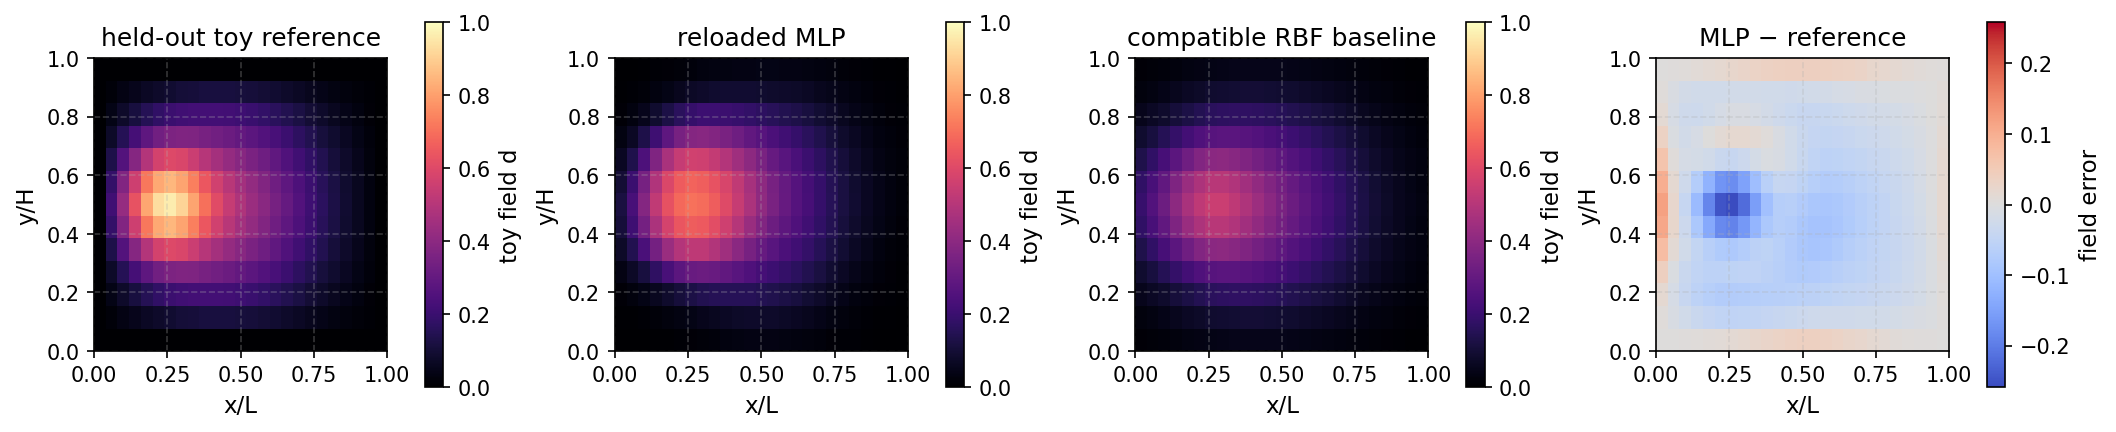

In [5]:
def field_image(values):
    return values.detach().reshape(problem.ny, problem.nx).cpu().numpy()

error = prediction_after - heldout_reference
error_limit = max(float(error.abs().max()), torch.finfo(torch.float64).eps)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), constrained_layout=True)
for ax, values, title, cmap, limits in (
    (axes[0], heldout_reference, "held-out toy reference", "magma", (0, 1)),
    (axes[1], prediction_after, "reloaded MLP", "magma", (0, 1)),
    (axes[2], rbf_prediction, "compatible RBF baseline", "magma", (0, 1)),
    (axes[3], error, "MLP − reference", "coolwarm", (-error_limit, error_limit)),
):
    image = ax.imshow(field_image(values), origin="lower", extent=(0,1,0,1), cmap=cmap, vmin=limits[0], vmax=limits[1])
    ax.set(title=title, xlabel="x/L", ylabel="y/H", aspect="equal")
    fig.colorbar(image, ax=ax, shrink=0.78, label="field error" if ax is axes[3] else "toy field d")
fig.savefig(assets_dir() / "tiny_mlp_heldout_field.png", dpi=160, bbox_inches="tight")
display_figure(fig, alt="Held-out toy reference, reloaded MLP field, compatible RBF field, and MLP error.")
plt.close(fig)


## Interpreting the held-out fields

Read the reference, MLP, and radial-basis panels on their common field scale. The signed error panel shows where the MLP overestimates or underestimates the reference. The held-out RMSE measures average field agreement; the spatial pattern helps identify which regions deserve further training data.

The reload comparison checks that reconstructing the model from the stored architecture, weights, and normalisation reproduces its predictions on the tested input. Predictions at separate loads assess generalisation within this linear field problem.

An MLP and a Gaussian radial-basis weighted average both consume the present nodewise features. A CNN uses mesh-to-grid and grid-to-mesh mappings. A GNN or graph neural operator uses graph connectivity or operator-specific inputs. These mappings become part of the model interface when extending the tutorial.

The next notebook uses the saved model in a proposal, residual assessment, and reference-correction sequence.


## Key takeaways

- Whole-load data splits evaluate predictions at loading conditions held apart from training.
- Reverse-mode differentiation connects the mean-squared field loss to every trainable network parameter.
- A reusable checkpoint stores the input conventions and normalisation alongside the architecture and weights.
- Reload agreement checks reconstruction; reference fields at separate loads assess predictive accuracy.

## Exercises

Try each question before opening the hint or worked solution. Keep the original calculation as your reference.

### Exercise 1: Connect the data layout to the training gradient

The grid contains $25\times13$ nodes. Twelve whole load cases form the training set, and each node supplies the feature row $[x/L,y/H,\lambda]$ and one target value.

1. Determine the shapes of the combined training-feature and target tensors.
2. For $\mathcal L=M^{-1}\sum_i(\widehat d_i-d_i)^2$, derive $\partial\mathcal L/\partial\widehat d_i$ and use the chain rule to express $\nabla_{\boldsymbol\theta}\mathcal L$.
3. Explain why normalisation statistics are fitted on training inputs and reused for validation and test inputs. How does keeping whole load cases together affect the interpretation of test accuracy?

<details><summary>Hint 1</summary>

Count all nodewise rows across the training loads. Differentiate one squared error, then propagate that derivative through the network output. Think of normalisation as part of the model's input interface.

</details>

<details><summary>Worked solution 1</summary>

There are $N=25\times13=325$ nodes per load and $M=12N=3900$ training rows. The feature tensor has shape $(3900,3)$ and the target tensor has shape $(3900,1)$.

For each row,

$$
\frac{\partial\mathcal L}{\partial\widehat d_i}
=\frac{2}{M}(\widehat d_i-d_i),
\qquad
\nabla_{\boldsymbol\theta}\mathcal L
=\sum_{i=1}^{M}\frac{2}{M}(\widehat d_i-d_i)
\nabla_{\boldsymbol\theta}f_{\boldsymbol\theta}(\mathbf z_i).
$$

The notebook's training helper computes these derivatives with `loss.backward()`. Adam then updates the parameters using the accumulated gradients.

Training-only statistics define a fixed transformation available when the model is deployed. Reusing them gives validation, test, and future inputs the same meaning. Keeping every node from one load case in a single split evaluates a new loading condition; randomly splitting nodes within one field also measures interpolation inside a field already represented during training.

</details>

### Exercise 2: Inspect the model at three separate loads

Keep the trained checkpoint fixed and evaluate load factors $0.82$, $0.94$, and $1.00$.

1. For each load, compute the reloaded MLP prediction, the reference field, the RMSE, and the maximum absolute error.
2. Plot the three signed error fields on a common colour scale.
3. Identify the validation and test cases from `metadata['splits']`. Explain what the error patterns suggest about prediction at loads beyond the training interval. Which additional experiment would test sensitivity to the spatial smoothing length $\ell$?

<details><summary>Hint 2</summary>

Use `problem.features(load)`, `problem.reference_field(load)`, and the saved `mean` and `scale`. Reuse `reloaded` under `torch.no_grad()`. Inspect the spatial errors as well as their aggregate norms.

</details>

<details><summary>Worked solution 2</summary>

The following cell uses the existing notebook variables and leaves the trained model fixed:

```python
loads_to_check = (0.82, 0.94, 1.00)
errors = []
for load in loads_to_check:
    features = problem.features(load)
    with torch.no_grad():
        predicted = reloaded(normalise_features(features, mean, scale)).squeeze(1)
    target = problem.reference_field(load)
    error = predicted - target
    errors.append(error)
    print({
        "load": load,
        "rmse": float(error.square().mean().sqrt()),
        "max_abs_error": float(error.abs().max()),
    })

limit = max(float(error.abs().max()) for error in errors)
fig, axes = plt.subplots(1, 3, figsize=(11, 3), constrained_layout=True)
for ax, load, error in zip(axes, loads_to_check, errors):
    im = ax.imshow(
        field_image(error), origin="lower", extent=(0, 1, 0, 1),
        cmap="coolwarm", vmin=-limit, vmax=limit,
    )
    ax.set(xlabel="x/L", ylabel="y/H", title=f"Load factor {load:.2f}")
fig.colorbar(im, ax=axes, label="Predicted minus reference field (dimensionless)")
plt.show()
```

The $0.82$ case belongs to validation; $0.94$ and $1.00$ belong to the test split. All three exceed the largest training load, $0.76$, so the comparison explores extrapolation in the load coordinate of this fixed model problem. Use the calculated fields to describe where error is concentrated and whether it changes consistently with load.

To study $\ell$, generate reference fields at several smoothing lengths, add $\ell$ to the model input contract, and reserve whole smoothing-length/load combinations for evaluation. This changes the learning problem and requires retraining with the expanded features.

</details>